Análisis exploratorio de los articulos sobre violencia machista en España, periodico Publico publicado entre el 01 de enero de 2017 al 05 de marzo de 2026.

# Inicialización

In [1]:
%pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Importación de librerías

In [2]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud


Lectura del archivo JSON

In [3]:
pagina="PUBLICO"

In [4]:
path_json = f'TFM_filtrado/{"noticias_filtradas_ESP_"+pagina}.json'

if os.path.exists(path_json):
    with open(path_json,"r", encoding="utf-8") as f:
        data = json.load(f)
    
    df = pd.json_normalize(data)
    print(df.head())
else:
    print(f"El archivo {path_json} no existe.")


              ID_noticia   diario       fecha           país  \
0  ESP__20180308073919_1  PUBLICO  08/03/2018  No encontrado   
1  ESP__20180311072619_2  PUBLICO  11/03/2018  No encontrado   
2  ESP__20180313021930_3  PUBLICO  13/03/2018  No encontrado   
3  ESP__20180316222931_2  PUBLICO  16/03/2018  No encontrado   
4  ESP__20180316222931_4  PUBLICO  16/03/2018  No encontrado   

  ubicacion_noticia  conteo_delitos.violencia  conteo_delitos.abuso sexual  \
0   No especificada                       1.0                          NaN   
1   No especificada                       1.0                          NaN   
2   No especificada                       1.0                          NaN   
3   No especificada                       1.0                          NaN   
4   No especificada                       1.0                          NaN   

   conteo_delitos.acoso sexual  conteo_delitos.violacion  \
0                          NaN                       NaN   
1                         

# Información general del dataset

Eliminación de artículos repetidos

In [5]:
df =df.drop_duplicates(subset="ID_noticia")

Exploración de columnas

In [6]:
print("Columnas disponibles: ", df.columns.tolist())

Columnas disponibles:  ['ID_noticia', 'diario', 'fecha', 'país', 'ubicacion_noticia', 'conteo_delitos.violencia', 'conteo_delitos.abuso sexual', 'conteo_delitos.acoso sexual', 'conteo_delitos.violacion', 'conteo_delitos.violaciones', 'conteo_delitos.violencia sexual', 'conteo_delitos.violencia contra la mujer', 'conteo_delitos.violencia machista', 'conteo_delitos.violencia intrafamiliar', 'conteo_delitos.feminicidio', 'conteo_delitos.machismo', 'conteo_delitos.asesinatos de mujeres', 'conteo_delitos.violencia vicaria', 'conteo_delitos.misoginia', 'conteo_delitos.violencia digital', 'conteo_delitos.matrimonio forzado', 'conteo_delitos.violencia de genero', 'conteo_delitos.ciberviolencia', 'conteo_delitos.techo de cristal', 'conteo_delitos.violencia familiar', 'conteo_delitos.pornografia', 'conteo_delitos.violencia institucional', 'conteo_delitos.sexismo', 'conteo_delitos.trata de mujeres', 'conteo_delitos.grooming']


Identificación de columnas de delitos

In [7]:
delitos_cols = [col for col in df.columns if "conteo_delitos." in col]
print("Número de delitos detectados:", len(delitos_cols))
delitos_cols[:10]

Número de delitos detectados: 25


['conteo_delitos.violencia',
 'conteo_delitos.abuso sexual',
 'conteo_delitos.acoso sexual',
 'conteo_delitos.violacion',
 'conteo_delitos.violaciones',
 'conteo_delitos.violencia sexual',
 'conteo_delitos.violencia contra la mujer',
 'conteo_delitos.violencia machista',
 'conteo_delitos.violencia intrafamiliar',
 'conteo_delitos.feminicidio']

# Análisis exploratorio de información

Noticias por país

In [8]:
df["país"].value_counts()


país
España           135
No encontrado     36
Name: count, dtype: int64

In [9]:
df["país"].value_counts(normalize=True) * 100

país
España           78.947368
No encontrado    21.052632
Name: proportion, dtype: float64

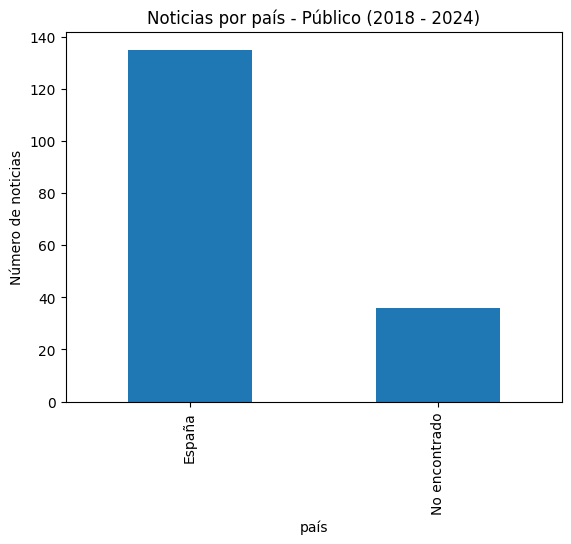

In [10]:
df["país"].value_counts().plot(kind="bar")

import matplotlib.pyplot as plt

plt.title("Noticias por país - Público (2018 - 2024)")
plt.ylabel("Número de noticias")
plt.show()

Fecha a formato de análisis

In [11]:
df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True, errors='coerce')

df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month

print(df[['fecha', 'año', 'mes']].head())

       fecha   año  mes
0 2018-03-08  2018    3
1 2018-03-11  2018    3
2 2018-03-13  2018    3
3 2018-03-16  2018    3
4 2018-03-16  2018    3


---


# Fechas


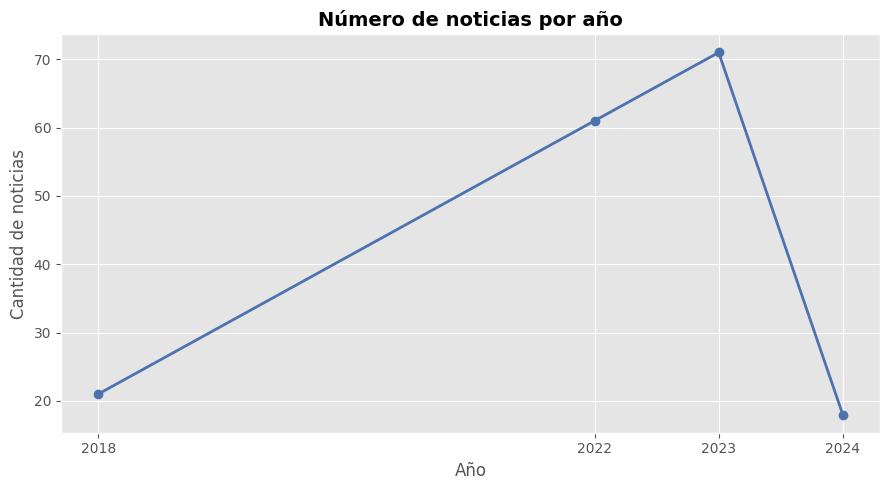

In [12]:
noticias_anio = df["año"].value_counts().sort_index()

plt.style.use("ggplot")

plt.figure(figsize=(9,5))

plt.plot(
    noticias_anio.index,
    noticias_anio.values,
    marker="o",
    linewidth=2,
        color="#4C72B0"

)

plt.title("Número de noticias por año", fontsize=14, weight="bold")
plt.xlabel("Año", fontsize=12)
plt.ylabel("Cantidad de noticias", fontsize=12)

plt.xticks(noticias_anio.index)

plt.tight_layout()
plt.show()

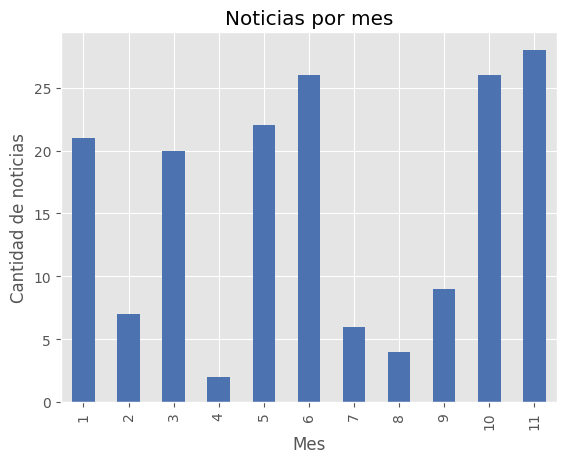

In [13]:
noticias_mes = df["mes"].value_counts().sort_index()

noticias_mes.plot(kind="bar",color="#4C72B0"
)
plt.style.use("ggplot")

plt.title("Noticias por mes")
plt.ylabel("Cantidad de noticias")
plt.xlabel("Mes")
plt.show()

# Palabras

In [14]:
totales_delitos = df[delitos_cols].sum().sort_values(ascending=False)

# limpiar nombres
delitos_limpios = totales_delitos.copy()
delitos_limpios.index = delitos_limpios.index.str.replace("conteo_delitos.", "")

delitos_limpios.head(10)

violencia                  1349.0
violencia machista          227.0
feminicidio                 170.0
violencia sexual             69.0
machismo                     58.0
violencia vicaria            53.0
acoso sexual                 48.0
asesinatos de mujeres        24.0
abuso sexual                 24.0
violencia institucional      20.0
dtype: float64

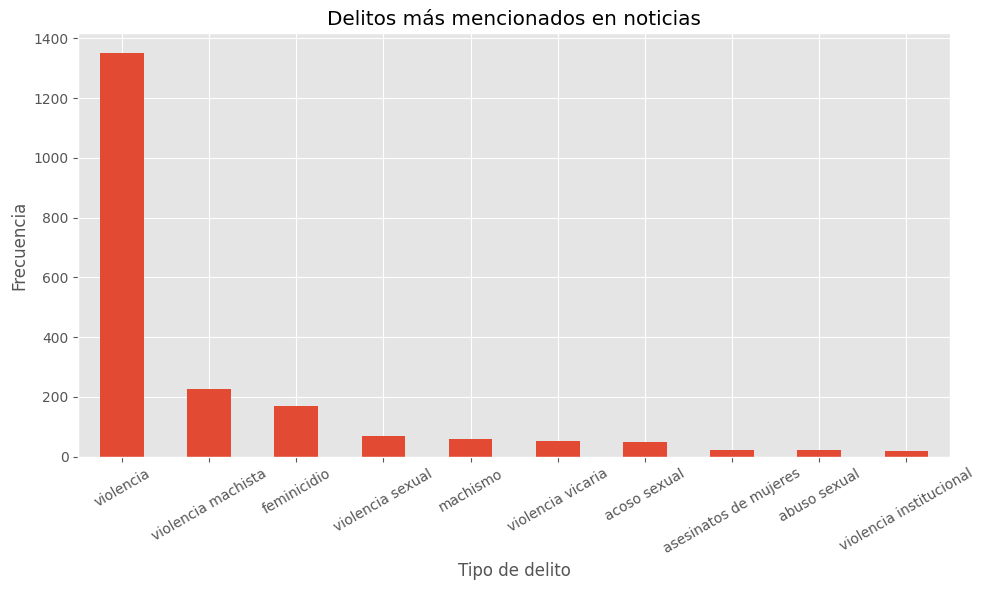

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

delitos_limpios.head(10).plot(kind="bar")

plt.title("Delitos más mencionados en noticias")
plt.ylabel("Frecuencia")
plt.xlabel("Tipo de delito")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

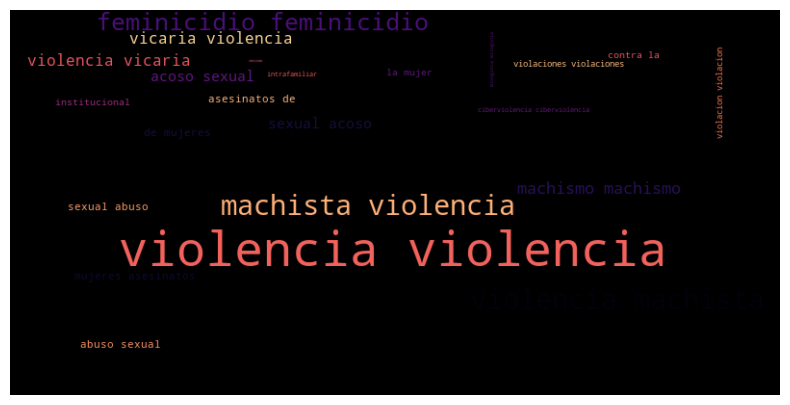

In [16]:
# limpiar nombres de delitos
delitos_limpios = totales_delitos.copy()
delitos_limpios.index = delitos_limpios.index.str.replace("conteo_delitos.", "")

# generar texto según frecuencia
texto_delitos = " ".join(delitos_limpios.index.repeat(delitos_limpios.astype(int)))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="black",
    colormap="magma"
).generate(texto_delitos)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
#plt.title("Delitos más mencionados en noticias")
plt.show()

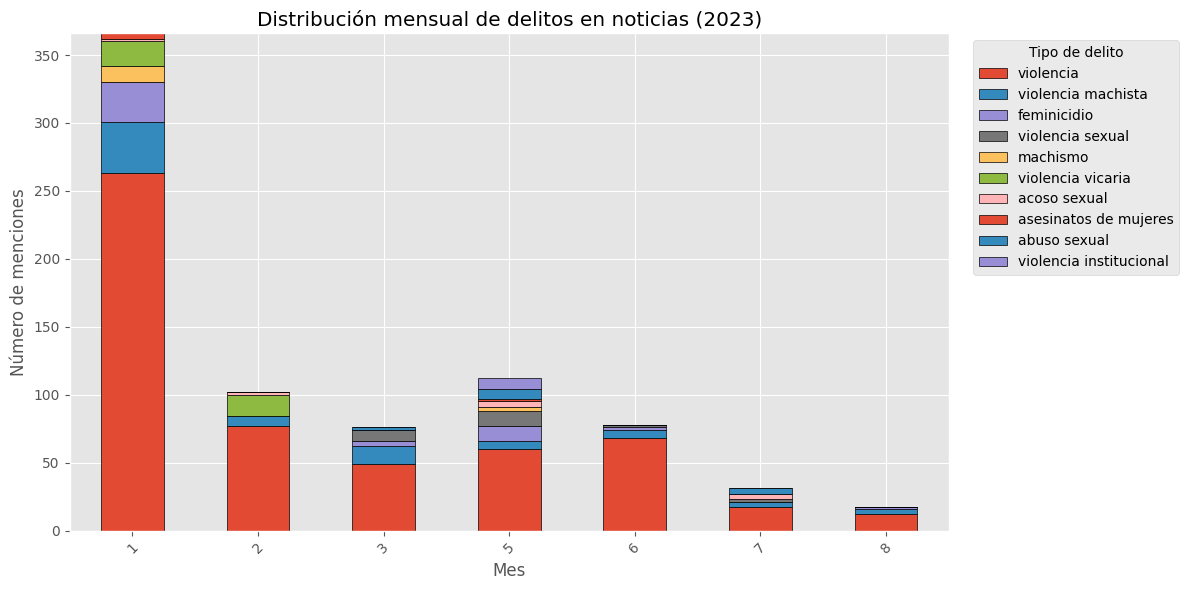

In [17]:
# Análisis mensual del Top 10 delitos en noticias de 2023

plt.style.use("ggplot")

# 1️⃣ Filtrar año
df_2023 = df[df["año"] == 2023]

# 2️⃣ Top delitos usando nombres originales
top_delitos = totales_delitos.head(10).index

# 3️⃣ Agrupar por mes
delitos_mes = df_2023.groupby("mes")[top_delitos].sum()

# 4️⃣ Limpiar nombres SOLO para visualización
delitos_mes.columns = delitos_mes.columns.str.replace("conteo_delitos.", "")

# 5️⃣ Ordenar meses
delitos_mes = delitos_mes.sort_values(by="mes")

# 6️⃣ Graficar
delitos_mes.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    edgecolor="black",

)

plt.xlabel("Mes")
plt.ylabel("Número de menciones")
plt.title("Distribución mensual de delitos en noticias (2023)")

plt.xticks(rotation=45)

plt.legend(
    title="Tipo de delito",
    bbox_to_anchor=(1.02,1),
    loc="upper left"

)

plt.tight_layout()
plt.show()

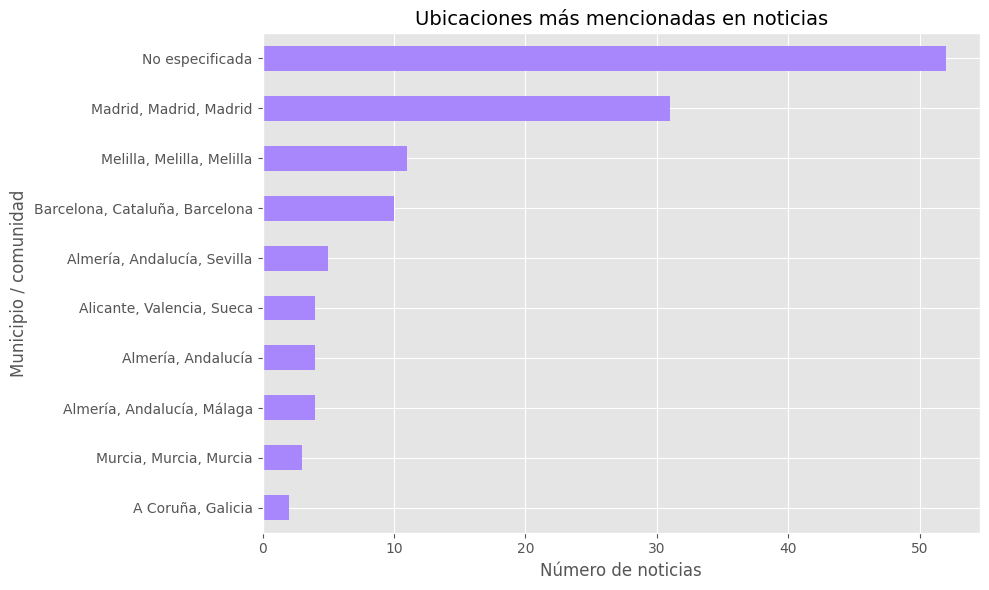

In [18]:
plt.style.use("ggplot")

top_ubicaciones = df["ubicacion_noticia"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_ubicaciones.sort_values().plot(
    kind="barh",
    color="#A887FD"
)

plt.title("Ubicaciones más mencionadas en noticias", fontsize=14)
plt.xlabel("Número de noticias")
plt.ylabel("Municipio / comunidad")

plt.tight_layout()
plt.show()

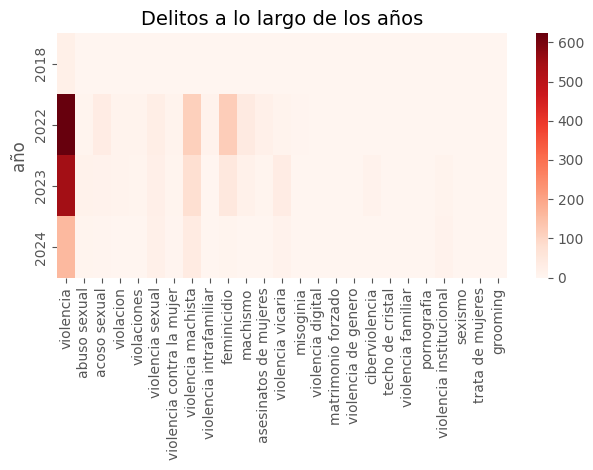

In [19]:

# Agrupar delitos por año
delitos_anio = df.groupby("año")[delitos_cols].sum()

# Limpiar nombres de columnas
delitos_anio.columns = delitos_anio.columns.str.replace("conteo_delitos.", "", regex=False)

# Crear heatmap
sns.heatmap(
    delitos_anio, 
    cmap="Reds",
)

plt.title("Delitos a lo largo de los años", fontsize=14)

plt.tight_layout()
plt.show()

In [20]:
for col in df.columns:
    print(col)

ID_noticia
diario
fecha
país
ubicacion_noticia
conteo_delitos.violencia
conteo_delitos.abuso sexual
conteo_delitos.acoso sexual
conteo_delitos.violacion
conteo_delitos.violaciones
conteo_delitos.violencia sexual
conteo_delitos.violencia contra la mujer
conteo_delitos.violencia machista
conteo_delitos.violencia intrafamiliar
conteo_delitos.feminicidio
conteo_delitos.machismo
conteo_delitos.asesinatos de mujeres
conteo_delitos.violencia vicaria
conteo_delitos.misoginia
conteo_delitos.violencia digital
conteo_delitos.matrimonio forzado
conteo_delitos.violencia de genero
conteo_delitos.ciberviolencia
conteo_delitos.techo de cristal
conteo_delitos.violencia familiar
conteo_delitos.pornografia
conteo_delitos.violencia institucional
conteo_delitos.sexismo
conteo_delitos.trata de mujeres
conteo_delitos.grooming
año
mes


In [21]:
delitos_cols = [c for c in df.columns if "conteo_delitos." in c]

print(len(delitos_cols))
print(delitos_cols[:5])


25
['conteo_delitos.violencia', 'conteo_delitos.abuso sexual', 'conteo_delitos.acoso sexual', 'conteo_delitos.violacion', 'conteo_delitos.violaciones']


In [22]:
totales_delitos = df[delitos_cols].sum().sort_values(ascending=False)

totales_delitos

conteo_delitos.violencia                    1349.0
conteo_delitos.violencia machista            227.0
conteo_delitos.feminicidio                   170.0
conteo_delitos.violencia sexual               69.0
conteo_delitos.machismo                       58.0
conteo_delitos.violencia vicaria              53.0
conteo_delitos.acoso sexual                   48.0
conteo_delitos.asesinatos de mujeres          24.0
conteo_delitos.abuso sexual                   24.0
conteo_delitos.violencia institucional        20.0
conteo_delitos.violencia contra la mujer      18.0
conteo_delitos.violacion                      17.0
conteo_delitos.violaciones                    16.0
conteo_delitos.violencia intrafamiliar        10.0
conteo_delitos.ciberviolencia                 10.0
conteo_delitos.misoginia                       6.0
conteo_delitos.sexismo                         3.0
conteo_delitos.violencia familiar              2.0
conteo_delitos.violencia de genero             2.0
conteo_delitos.violencia digita